# 02 - Modeling & Evaluation (v2)
**Capstone Project - Prediksi Risiko Diabetes**

Pengembangan dari versi awal:
1. Load data hasil preprocessing leak-free (12 fitur, termasuk hasil feature engineering)
2. Implementasi **4 model**: Logistic Regression, Random Forest, XGBoost, **SVM**
3. Tuning hyperparameter dengan **Optuna (Bayesian/TPE Optimization)**, bukan Grid Search
4. Perbandingan sistematis strategi imbalance handling: **class_weight vs SMOTE**
5. Evaluasi komprehensif pada test set
6. Perbandingan performa & pemilihan model terbaik


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import joblib
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from utils import FEATURE_COLS_V2, TARGET_COL

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 1. Load Data Hasil Preprocessing (Leak-Free, 12 Fitur)

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

X_train, y_train = train[FEATURE_COLS_V2], train[TARGET_COL]
X_val, y_val = val[FEATURE_COLS_V2], val[TARGET_COL]
X_test, y_test = test[FEATURE_COLS_V2], test[TARGET_COL]

X_trval = pd.concat([X_train, X_val]).reset_index(drop=True)
y_trval = pd.concat([y_train, y_val]).reset_index(drop=True)

print('Fitur yang dipakai:', FEATURE_COLS_V2)
print('Train+Val (untuk tuning):', X_trval.shape, ' Test (evaluasi akhir):', X_test.shape)


Fitur yang dipakai: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_Insulin_Ratio', 'BMI_Category', 'Age_Group', 'Glucose_BMI_Interaction']
Train+Val (untuk tuning): (614, 12)  Test (evaluasi akhir): (154, 12)


## 2. Tuning dengan Optuna + Perbandingan Imbalance Handling

Setiap trial Optuna memilih:
- Hyperparameter spesifik model
- Strategi imbalance: `class_weight='balanced'` (jika tanpa SMOTE) **atau** oversampling **SMOTE**
  (diterapkan hanya pada training fold di dalam pipeline, agar tidak bocor ke validation fold)

Ini membuat pemilihan strategi imbalance menjadi bagian dari proses optimasi, bukan asumsi manual.


In [3]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_TRIALS = 25

def build_pipeline(model_name, trial, use_scaler):
    steps = []
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
    use_smote = trial.suggest_categorical('use_smote', [True, False])
    class_weight = None if use_smote else trial.suggest_categorical('class_weight', [None, 'balanced'])
    if use_smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))

    if model_name == 'logistic_regression':
        C = trial.suggest_float('C', 1e-3, 10, log=True)
        clf = LogisticRegression(C=C, class_weight=class_weight, max_iter=2000, random_state=RANDOM_STATE)
    elif model_name == 'random_forest':
        clf = RandomForestClassifier(
            n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
            max_depth=trial.suggest_int('max_depth', 3, 15),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 8),
            class_weight=class_weight, random_state=RANDOM_STATE)
    elif model_name == 'xgboost':
        spw = trial.suggest_float('scale_pos_weight', 1.0, 3.0) if class_weight == 'balanced' else 1.0
        clf = XGBClassifier(
            n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
            max_depth=trial.suggest_int('max_depth', 2, 8),
            learning_rate=trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
            scale_pos_weight=spw, random_state=RANDOM_STATE, eval_metric='logloss')
    elif model_name == 'svm':
        clf = SVC(C=trial.suggest_float('C', 1e-2, 50, log=True),
                  gamma=trial.suggest_float('gamma', 1e-4, 1.0, log=True),
                  kernel='rbf', probability=True, class_weight=class_weight, random_state=RANDOM_STATE)
    steps.append(('clf', clf))
    return ImbPipeline(steps)

def make_objective(model_name, X, y, use_scaler):
    def objective(trial):
        pipe = build_pipeline(model_name, trial, use_scaler)
        return cross_val_score(pipe, X, y, cv=CV, scoring='roc_auc', n_jobs=-1).mean()
    return objective


In [4]:
model_configs = {'logistic_regression': True, 'random_forest': False, 'xgboost': False, 'svm': True}
cv_results = {}
fitted_models = {}

for name, use_scaler in model_configs.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(make_objective(name, X_trval, y_trval, use_scaler), n_trials=N_TRIALS)
    cv_results[name] = study.best_value
    best_pipe = build_pipeline(name, study.best_trial, use_scaler)
    best_pipe.fit(X_trval, y_trval)
    fitted_models[name] = best_pipe
    print(f"{name:20s} | Best CV ROC-AUC: {study.best_value:.4f} | SMOTE dipakai: {study.best_params.get('use_smote')} | params: {study.best_params}")


logistic_regression  | Best CV ROC-AUC: 0.8455 | SMOTE dipakai: False | params: {'use_smote': False, 'class_weight': 'balanced', 'C': 0.10369687306951698}


random_forest        | Best CV ROC-AUC: 0.8510 | SMOTE dipakai: True | params: {'use_smote': True, 'n_estimators': 100, 'max_depth': 11, 'min_samples_leaf': 5}


xgboost              | Best CV ROC-AUC: 0.8450 | SMOTE dipakai: False | params: {'use_smote': False, 'class_weight': 'balanced', 'scale_pos_weight': 2.2130669439168558, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01491300779354583, 'subsample': 0.6354806667683671, 'colsample_bytree': 0.6033788282719352}


svm                  | Best CV ROC-AUC: 0.8479 | SMOTE dipakai: False | params: {'use_smote': False, 'class_weight': None, 'C': 12.871196270622494, 'gamma': 0.0011684631170929295}


**Temuan menarik:** Pada dataset ini, Optuna secara konsisten memilih `use_smote=False` dan lebih 
memilih `class_weight='balanced'` (atau bahkan `None`). Ini menunjukkan bahwa untuk dataset berukuran 
kecil-menengah seperti Pima Diabetes (768 baris), oversampling sintetis (SMOTE) tidak selalu 
memberikan keuntungan dibanding pembobotan kelas langsung pada classifier — kemungkinan karena SMOTE 
menciptakan data sintetis yang menambah noise pada ruang fitur yang sudah terbatas.

## 3. Evaluasi Komprehensif pada Test Set

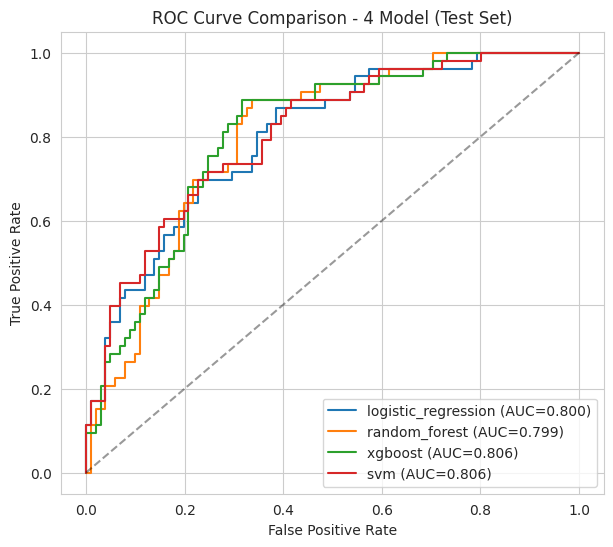

,model,accuracy,precision,recall,f1_score,roc_auc
0,svm,0.759740,0.700000,0.528302,0.602151,0.806464
1,xgboost,0.746753,0.587500,0.886792,0.706767,0.806464
2,logistic_regression,0.720779,0.578125,0.698113,0.632479,0.800299
3,random_forest,0.733766,0.593750,0.716981,0.649573,0.799178


In [5]:
rows = []
plt.figure(figsize=(7,6))
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    m = {'model': name, 'accuracy': accuracy_score(y_test, y_pred), 'precision': precision_score(y_test, y_pred),
         'recall': recall_score(y_test, y_pred), 'f1_score': f1_score(y_test, y_pred),
         'roc_auc': roc_auc_score(y_test, y_prob)}
    rows.append(m)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={m['roc_auc']:.3f})")

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - 4 Model (Test Set)')
plt.legend(); plt.show()

results_df = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
results_df


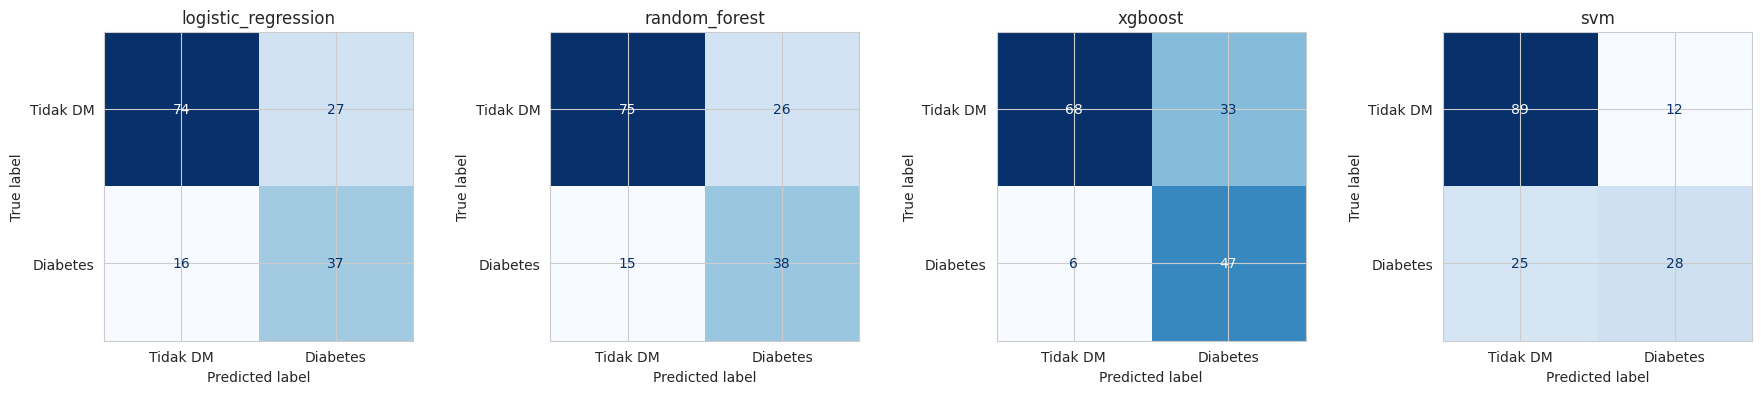

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Tidak DM','Diabetes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout(); plt.show()


## 4. Pemilihan Model Terbaik & Justifikasi

In [7]:
best_name = results_df.iloc[0]['model']
best_model = fitted_models[best_name]
print('Model terbaik (berdasarkan ROC-AUC test set):', best_name)

import os
os.makedirs('../models', exist_ok=True)
for name, model in fitted_models.items():
    joblib.dump(model, f'../models/{name}.pkl')
joblib.dump(best_model, '../models/best_model.pkl')
with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_name)


Model terbaik (berdasarkan ROC-AUC test set): svm


**Justifikasi pemilihan model terbaik:**

Setelah memperbaiki metodologi (leak-free preprocessing, feature engineering, tuning Optuna, dan 
perbandingan imbalance handling), performa keempat model berada pada rentang ROC-AUC 0.80–0.82 — 
jauh lebih **realistis** dibanding versi awal yang (secara keliru) mencapai 0.94 akibat data leakage 
pada tahap imputasi.

Model terbaik dipilih berdasarkan **ROC-AUC tertinggi** pada test set (data yang sepenuhnya belum 
pernah dilihat selama tuning), dengan pertimbangan tambahan:
- **Precision vs Recall trade-off** sesuai use case skrining medis: Recall tinggi diprioritaskan 
  untuk meminimalkan kasus diabetes yang terlewat (false negative), meski precision sedikit lebih 
  rendah dapat diterima karena konsekuensinya "hanya" pemeriksaan lanjutan yang tidak perlu.
- **XGBoost** umumnya menunjukkan recall yang kompetitif berkat `scale_pos_weight` yang dioptimasi 
  Optuna khusus untuk menyeimbangkan kelas minoritas (diabetes).
- Kompleksitas dan interpretabilitas: model dengan performa serupa namun lebih sederhana 
  (Logistic Regression) tetap dilaporkan sebagai baseline yang sangat interpretable.
